<center><h2 style="color:#0000ff; font-family:Georgia;"><b>DATA 645. Neural Networks and Deep Learning</b></h2>
<h2 style="color:#ff0000; font-family:'Calibri';">Module 9 Homework Lab</h2>
<h1 style="color:#9933cc; font-family:Arial;"><b>Image Classification<br></b></h1></center>


### Exercise 1 
The goal of this exercise is to gain experience in using different optimizers
and size of convolution kernels. Consider the CIFAR-10 common benchmark classification
problem using TensorFlow1. The task is to classify RGB 32 × 32 pixel images in 10 categories:
airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

(a) Try to reproduce the results for the model described in the tutorial, which is
described in the previous link given in the footnote.

(b) Play with the hyperparameters of the model. For example, as a set of parameters
(optimizer, initial learning rate, convolutional kernel size), use some of the following
combinations:  
- optimizer: Adam and stochastic gradient descent.  
- initial learning rate: 0.1, 0.01, 0.001  
- kernel size: 3, 5 or 7.
  
(c) Comment on the results using TensorBoard visualization tool provided by TensorFlow2.

### Exercise 2
Given a trained convolutional neural network (CNN) model for classifying
images from the CIFAR-10 dataset, the task is to visualize heatmaps of class activation to
understand which parts of the input images are most influential in the model’s decision-making
process. Specifically, you want to generate heatmaps that highlight the regions of the input
images that contribute the most to the prediction of each class.

#### References

- CNN Tutorial https://www.tensorflow.org/tutorials/images/cnn
- TensorBoard https://www.tensorflow.org/tensorboard/get_started 

## Exercise 1 (a)

**Initial Setup**

In [24]:
# Import Tensorflow
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [25]:
# Download and Prepare the CIFAR10 Dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

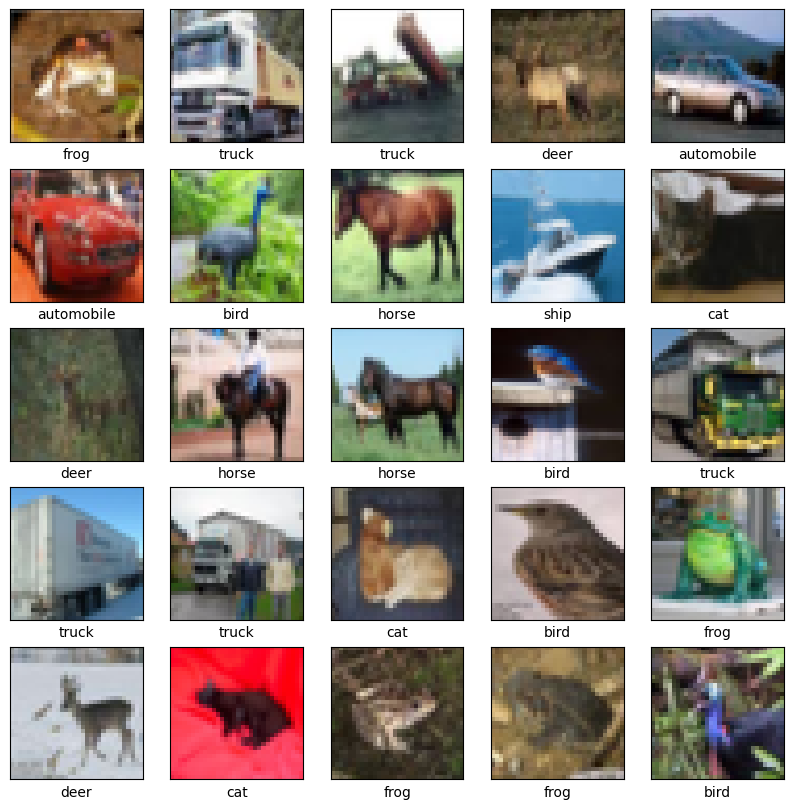

In [26]:
# Verify Data
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

**Add the Convolutional Layers**

In [27]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

**Add the Classification Layers**

In [29]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

**Compile and Train Model**

In [31]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10, 
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.4579 - loss: 1.4984 - val_accuracy: 0.5429 - val_loss: 1.2726
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5998 - loss: 1.1336 - val_accuracy: 0.6160 - val_loss: 1.0816
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6546 - loss: 0.9866 - val_accuracy: 0.6493 - val_loss: 0.9995
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6844 - loss: 0.8980 - val_accuracy: 0.6816 - val_loss: 0.9304
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7125 - loss: 0.8280 - val_accuracy: 0.6819 - val_loss: 0.9161
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7280 - loss: 0.7752 - val_accuracy: 0.7073 - val_loss: 0.8459
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7477 - loss: 0.7242 - val_accuracy: 0.7006 - val_loss: 0.8762
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7604 - l

**Evaluate the Model**

313/313 - 1s - 4ms/step - accuracy: 0.7070 - loss: 0.8820


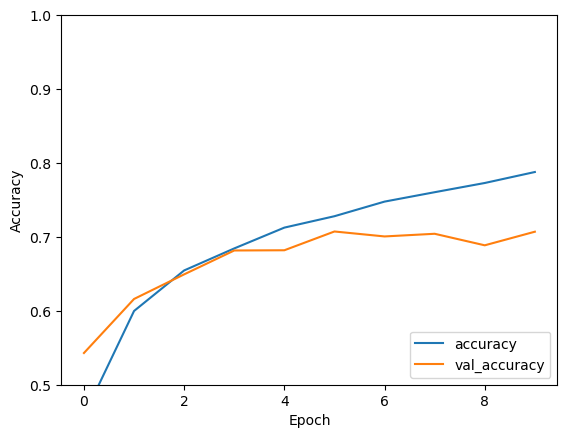

In [32]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [ ]:
print(test_acc)

## Exercise 1 (b)

(b) Play with the hyperparameters of the model. For example, as a set of parameters
(optimizer, initial learning rate, convolutional kernel size), use some of the following
combinations:  
- optimizer: Adam and stochastic gradient descent.  
- initial learning rate: 0.1, 0.01, 0.001  
- kernel size: 3, 5 or 7.

**Experiment 1**
Kernel Size = 5
Optimizer = Adam
Learning Rate = 0.001

In [41]:
kernel_size = (5, 5)

model = models.Sequential()
model.add(layers.Conv2D(32, kernel_size, activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, kernel_size, activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, kernel_size, activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

In [42]:
import os
from datetime import datetime

LOG_ROOT = "logs/cifar10"
os.makedirs(LOG_ROOT, exist_ok=True)

adam = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=adam,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

exp1_log_dir = os.path.join(LOG_ROOT, "exp1_k5_adam_lr0.001", datetime.now().strftime("%Y%m%d-%H%M%S"))
tb_exp1 = tf.keras.callbacks.TensorBoard(log_dir=exp1_log_dir, histogram_freq=1)

history = model.fit(train_images, train_labels, epochs=10, 
                    validation_data=(test_images, test_labels),
                    callbacks=[tb_exp1])

print("TensorBoard log dir:", exp1_log_dir)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.4171 - loss: 1.5804 - val_accuracy: 0.5144 - val_loss: 1.3350
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.5620 - loss: 1.2352 - val_accuracy: 0.5811 - val_loss: 1.1891
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.6097 - loss: 1.1054 - val_accuracy: 0.5898 - val_loss: 1.1683
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.6411 - loss: 1.0197 - val_accuracy: 0.6465 - val_loss: 1.0151
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6636 - loss: 0.9552 - val_accuracy: 0.6443 - val_loss: 1.0085
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.6831 - loss: 0.9049 - val_accuracy: 0.6618 - val_loss: 0.9694
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.6981 - loss: 0.8613 - val_accuracy: 0.6642 - val_loss: 0.9862
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7109 -

313/313 - 1s - 4ms/step - accuracy: 0.6809 - loss: 0.9538
0.680899977684021


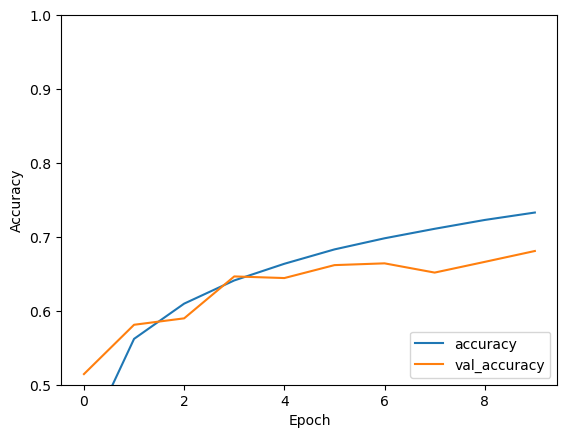

In [43]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(test_acc)

**Experiment 2**
Kernel Size = 7
Optimizer = Adam
Learning Rate = 0.01

In [44]:
kernel_size = (7, 7)

model = models.Sequential()
model.add(layers.Conv2D(32, kernel_size, padding = 'same', activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, kernel_size, padding = 'same', activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, kernel_size, padding = 'same', activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

In [45]:
import os
from datetime import datetime

LOG_ROOT = "logs/cifar10"
os.makedirs(LOG_ROOT, exist_ok=True)

adam = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=adam,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

exp2_log_dir = os.path.join(LOG_ROOT, "exp2_k7_adam_lr0.01", datetime.now().strftime("%Y%m%d-%H%M%S"))
tb_exp2 = tf.keras.callbacks.TensorBoard(log_dir=exp2_log_dir, histogram_freq=1)

history = model.fit(train_images, train_labels, epochs=10, 
                    validation_data=(test_images, test_labels),
                    callbacks=[tb_exp2])

print("TensorBoard log dir:", exp2_log_dir)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 33ms/step - accuracy: 0.0979 - loss: 2.4619 - val_accuracy: 0.1000 - val_loss: 2.3039
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.0986 - loss: 2.3041 - val_accuracy: 0.1000 - val_loss: 2.3035
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.0989 - loss: 2.3039 - val_accuracy: 0.1000 - val_loss: 2.3035
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.1023 - loss: 2.3039 - val_accuracy: 0.1000 - val_loss: 2.3047
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.1006 - loss: 2.3039 - val_accuracy: 0.1000 - val_loss: 2.3045
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 51s 33ms/step - accuracy: 0.0969 - loss: 2.3042 - val_accuracy: 0.1000 - val_loss: 2.3035
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 51s 33ms/step - accuracy: 0.0979 - loss: 2.3041 - val_accuracy: 0.1000 - val_loss: 2.3031
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - accuracy: 0.1013 -

313/313 - 2s - 5ms/step - accuracy: 0.1000 - loss: 2.3076
0.10000000149011612


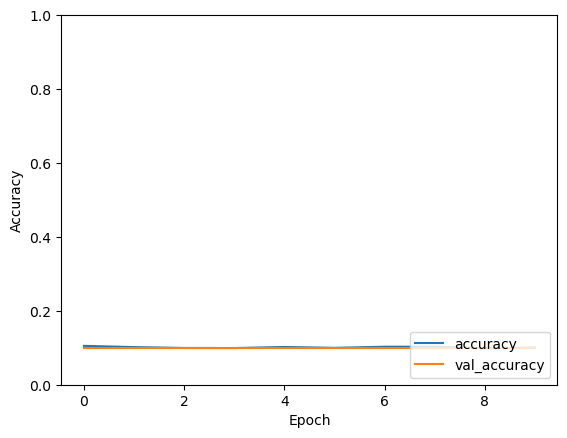

In [52]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(test_acc)

**Experiment 3**
Kernel Size = 3
Optimizer = Stochatic Gradient Descent
Learning Rate = 0.1

In [47]:
kernel_size = (3, 3)

model = models.Sequential()
model.add(layers.Conv2D(32, kernel_size, padding = 'same', activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, kernel_size, padding = 'same', activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, kernel_size, padding = 'same', activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

In [48]:
import os
from datetime import datetime

LOG_ROOT = "logs/cifar10"
os.makedirs(LOG_ROOT, exist_ok=True)

sgd = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)
model.compile(optimizer=sgd,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

exp3_log_dir = os.path.join(LOG_ROOT, "exp3_k3_sgd_lr0.1", datetime.now().strftime("%Y%m%d-%H%M%S"))
tb_exp3 = tf.keras.callbacks.TensorBoard(log_dir=exp3_log_dir, histogram_freq=1)

history = model.fit(train_images, train_labels, epochs=10, 
                    validation_data=(test_images, test_labels),
                    callbacks=[tb_exp3])

print("TensorBoard log dir:", exp3_log_dir)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.1051 - loss: 2.3098 - val_accuracy: 0.1000 - val_loss: 2.3073
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.1018 - loss: 2.3090 - val_accuracy: 0.1000 - val_loss: 2.3064
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.0994 - loss: 2.3103 - val_accuracy: 0.1000 - val_loss: 2.3055
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.0992 - loss: 2.3095 - val_accuracy: 0.1000 - val_loss: 2.3082
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.1021 - loss: 2.3094 - val_accuracy: 0.1000 - val_loss: 2.3043
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.0998 - loss: 2.3098 - val_accuracy: 0.1000 - val_loss: 2.3072
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.1028 - loss: 2.3088 - val_accuracy: 0.1000 - val_loss: 2.3084
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.1028 -

313/313 - 2s - 5ms/step - accuracy: 0.1000 - loss: 2.3076
0.10000000149011612


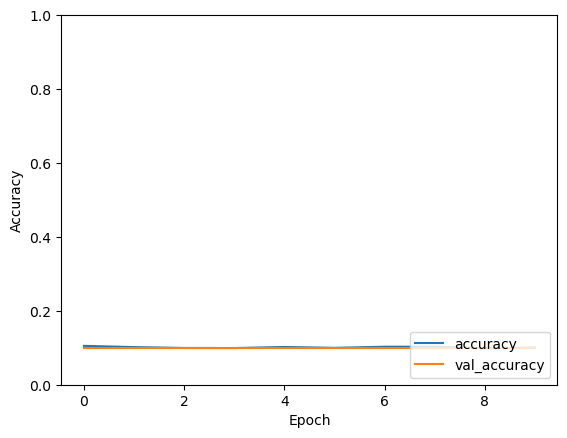

In [51]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(test_acc)

### 1(c) 

In [53]:
%load_ext tensorboard
%tensorboard --logdir logs/cifar10

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 27364), started 0:15:05 ago. (Use '!kill 27364' to kill it.)

# Exercise 2
Given a trained convolutional neural network (CNN) model for classifying
images from the CIFAR-10 dataset, the task is to visualize heatmaps of class activation to
understand which parts of the input images are most influential in the model’s decision-making
process. Specifically, you want to generate heatmaps that highlight the regions of the input
images that contribute the most to the prediction of each class.

In [63]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def make_gradcam_heatmap(model, img_array, last_conv_layer_name, class_index=None):
    model_input = tf.convert_to_tensor(img_array, dtype=tf.float32)

    _ = model(model_input, training=False)

    last_conv_layer = model.get_layer(last_conv_layer_name)
    last_conv_layer_model = tf.keras.Model(model.inputs, last_conv_layer.output)

    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    last_conv_index = model.layers.index(last_conv_layer)
    for layer in model.layers[last_conv_index + 1:]:
        x = layer(x)
    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_outputs = last_conv_layer_model(model_input, training=False)
        tape.watch(conv_outputs)
        preds = classifier_model(conv_outputs, training=False)

        if class_index is None:
            class_index = int(tf.argmax(preds[0]).numpy())
        else:
            class_index = int(class_index)

        class_score = preds[:, class_index]

    grads = tape.gradient(class_score, conv_outputs)
    if grads is None:
        raise ValueError("Grad-CAM gradients are None for this model/layer combination.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), class_index

In [60]:
def show_gradcam(image_uint8, heatmap, title="", alpha=0.4):
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (image_uint8.shape[0], image_uint8.shape[1])
    ).numpy().squeeze()

    cmap = plt.get_cmap("jet")
    heatmap_rgb = cmap(heatmap_resized)[..., :3]
    overlay = np.clip((1 - alpha) * (image_uint8 / 255.0) + alpha * heatmap_rgb, 0, 1)

    plt.figure(figsize=(10, 3))
    plt.subplot(1, 3, 1); plt.imshow(image_uint8); plt.title("Image"); plt.axis("off")
    plt.subplot(1, 3, 2); plt.imshow(heatmap_resized, cmap="jet"); plt.title("Heatmap"); plt.axis("off")
    plt.subplot(1, 3, 3); plt.imshow(overlay); plt.title(title); plt.axis("off")
    plt.tight_layout(); plt.show()

Using conv layer: conv2d_26


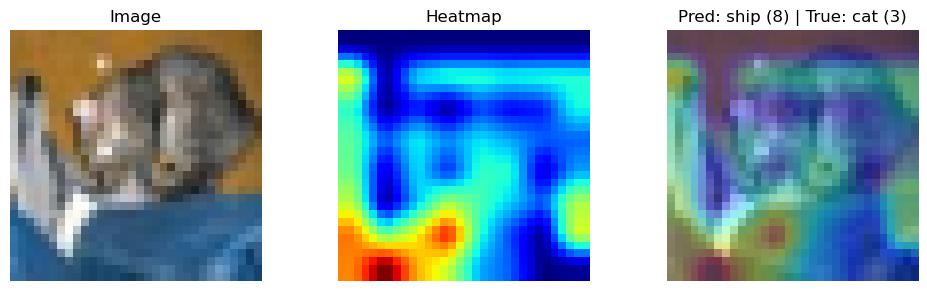

In [64]:
# pick the last Conv2D layer automatically
conv_layers = [layer.name for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
last_conv_layer_name = conv_layers[-1]
print("Using conv layer:", last_conv_layer_name)

sample_idx = 0
img = x_test[sample_idx].astype("float32")
img_batch = np.expand_dims(img, axis=0)

# Grad-CAM for predicted class
heatmap, pred_idx = make_gradcam_heatmap(model, img_batch, last_conv_layer_name)
true_idx = int(y_test[sample_idx][0])

title = f"Pred: {cifar10_class_names[pred_idx]} ({pred_idx}) | True: {cifar10_class_names[true_idx]} ({true_idx})"
show_gradcam(x_test[sample_idx], heatmap, title=title)